In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

np.random.seed(0)

# Task 0
def make_3d_moons(n_samples=3000, noise=0.2, random_state=0):
    X2, y = make_moons(
        n_samples=n_samples,
        noise=noise,
        random_state=random_state
    )
    x, y2 = X2[:, 0], X2[:, 1]
    z = 0.5 * np.sin(2 * x) + 0.1 * np.random.randn(n_samples)
    X3 = np.column_stack([x, y2, z])
    return X3, y

In [16]:
# Task 1
def make_torus(n_samples=2000, R=2.0, r=0.5, noise=0.05, random_state=0):
    rng = np.random.default_rng(random_state)
    u = rng.uniform(0, 2 * np.pi, n_samples)
    v = rng.uniform(0, 2 * np.pi, n_samples)
    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v)
    X = np.column_stack([x, y, z])
    X += noise * rng.standard_normal(X.shape)
    return X

def _set_3d_equalish_limits(ax, X_all):
    mins = X_all.min(axis=0)
    maxs = X_all.max(axis=0)
    center = (mins + maxs) / 2.0
    radius = (maxs - mins).max() / 2.0

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def plot_3d_scatter_tidy(X3, c, title):
    fig = plt.figure(figsize=(8, 6), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(
        X3[:, 0], X3[:, 1], X3[:, 2],
        c=c, cmap="viridis",
        vmin=0, vmax=2,
        s=6, alpha=0.75
    )

    _set_3d_equalish_limits(ax, X3)
    ax.view_init(elev=18, azim=55)
    ax.set_title(title, pad=10)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_ticks([0, 1, 2])
    plt.show()


def plot_3d_side_by_side_tidy(X_left, c_left, X_right, c_right, title_left, title_right):
    fig, axes = plt.subplots(
        1, 2, figsize=(12, 5),
        subplot_kw={"projection": "3d"},
        constrained_layout=True
    )

    X_all = np.vstack([X_left, X_right])

    sc1 = axes[0].scatter(
        X_left[:, 0], X_left[:, 1], X_left[:, 2],
        c=c_left, cmap="viridis",
        vmin=0, vmax=2,
        s=6, alpha=0.75
    )
    sc2 = axes[1].scatter(
        X_right[:, 0], X_right[:, 1], X_right[:, 2],
        c=c_right, cmap="viridis",
        vmin=0, vmax=2,
        s=6, alpha=0.75
    )

    for ax, ttl in zip(axes, [title_left, title_right]):
        _set_3d_equalish_limits(ax, X_all)
        ax.view_init(elev=18, azim=55)
        ax.set_title(ttl, pad=10)
        ax.set_xlabel("dim1")
        ax.set_ylabel("dim2")
        ax.set_zlabel("dim3")

    cbar = fig.colorbar(sc2, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_ticks([0, 1, 2])
    plt.show()

In [17]:
# Task 2
X_moons, y_moons = make_3d_moons(
    n_samples=5000,
    noise=0.15,
    random_state=1
)
X_moons[:, 0] *= 1.5
X_moons[:, 1] *= 1.5

X_torus = make_torus(
    n_samples=3000,
    R=3.8,
    r=0.6,
    noise=0.05,
    random_state=2
)
y_torus = np.full(X_torus.shape[0], 2)

X = np.vstack([X_moons, X_torus])
y = np.concatenate([y_moons, y_torus])

X.shape, np.unique(y, return_counts=True)


((8000, 3), (array([0, 1, 2]), array([2500, 2500, 3000])))

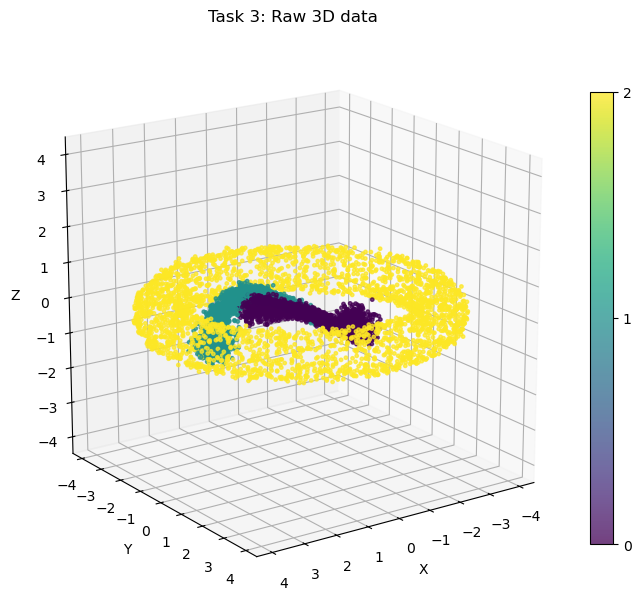

In [18]:
# Task 3
plot_3d_scatter_tidy(X[:, :3], y, "Task 3: Raw 3D data")

In [19]:
# Task 4
n_samples = X.shape[0]
X_noise = np.random.uniform(-4, 4, size=(n_samples, 7))
X_full = np.hstack([X, X_noise])

feature_names = [f"x{i}" for i in range(X_full.shape[1])]
yX = pd.DataFrame(X_full, columns=feature_names)
yX.insert(0, "y", y)

yX.head()

,y,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9
0,1,0.200369,0.179117,0.308401,-3.142837,1.319959,-0.703525,-1.923082,0.815611,-1.582479,0.246851
1,1,2.769694,0.436675,-0.221896,0.607819,0.232535,-3.914508,-1.210089,2.323698,-1.224835,0.075036
2,1,1.745790,-1.144202,0.461350,-1.226943,-2.406097,-2.401972,1.990877,1.023621,3.456456,-0.631963
3,1,0.929572,-0.560880,0.696888,1.092538,-0.251683,-0.208497,2.832699,-0.365578,3.425334,0.964058
4,1,0.009927,0.127628,0.193374,-3.316606,-3.456137,3.858514,-0.805125,0.699671,-0.547311,-2.728828


In [20]:
# Task 5
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((5600, 10), (2400, 10))

In [21]:
# Task 6
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
}

gbc = GradientBoostingClassifier(random_state=0)

grid_search = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,estimator,GradientBoost...andom_state=0)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.8, 1.0]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [22]:
# Task 7
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_summary = cv_results[["params", "mean_test_score", "rank_test_score"]].sort_values(
    by="mean_test_score", ascending=False
)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 160)

cv_summary

,params,mean_test_score,rank_test_score
40,"{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}",0.988214,1
46,"{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}",0.988214,2
50,"{'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}",0.988036,3
38,"{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}",0.987679,4
48,"{'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}",0.987679,4
52,"{'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}",0.987679,6
29,"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}",0.987500,7
22,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}",0.987500,7
44,"{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}",0.987500,7
47,"{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}",0.987500,7


In [23]:
# Task 8
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)
y_test_pred = best_model.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation Accuracy: 0.9882142857142858
Test Accuracy: 0.9858333333333333


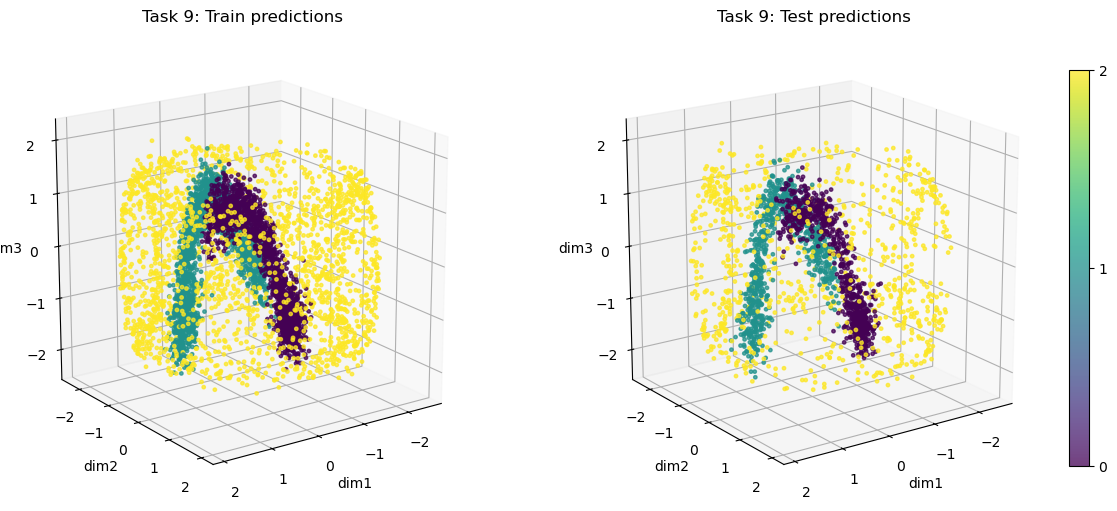

In [24]:
# Task 9
y_train_pred = best_model.predict(X_train_scaled)

plot_3d_side_by_side_tidy(
    X_train_scaled[:, :3], y_train_pred,
    X_test_scaled[:, :3],  y_test_pred,
    "Task 9: Train predictions",
    "Task 9: Test predictions"
)

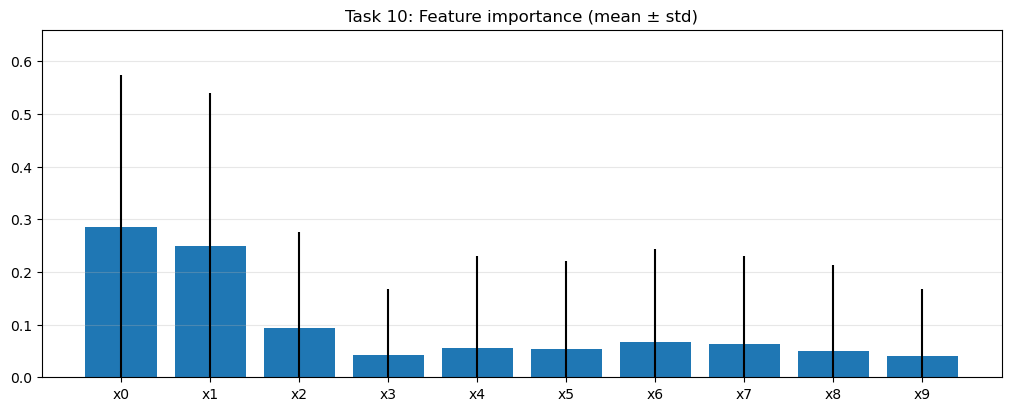

,feature,importance
1,x1,0.623916
0,x0,0.355559
2,x2,0.015577
6,x6,0.000965
7,x7,0.000926
4,x4,0.000926
5,x5,0.000710
9,x9,0.000608
8,x8,0.000540
3,x3,0.000274


In [25]:
# Task 10
importances = best_model.feature_importances_
all_trees = best_model.estimators_.ravel()
tree_imps = np.vstack([t.feature_importances_ for t in all_trees])

mean_imp = tree_imps.mean(axis=0)
std_imp = tree_imps.std(axis=0)

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.bar(range(len(mean_imp)), mean_imp, yerr=std_imp, align="center")
ax.set_xticks(range(len(mean_imp)))
ax.set_xticklabels(feature_names, rotation=0)
ax.set_title("Task 10: Feature importance (mean ± std)")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, (mean_imp + std_imp).max() * 1.15)
plt.show()

pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

In [26]:
# Task 11
True

True

[CV] END learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1.0; total time=  12.3s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.8; total time=  11.2s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   6.2s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=50, subsample=1.0; total time=   4.9s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=  15.8s
[CV] END learning_rate=0.2, max_depth=3, n_estimators=50, subsample=1.0; total time=   3.0s
[CV] END learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.8; total time=   9.8s
[CV] END learning_rate=0.2, max_depth=5, n_estimators=200, subsample=0.8; total time=  16.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, subsample=1.0; total time=   2.9s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=50, subsample=1.0; total time=   4.8s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=50, subsample=0